## Libraries & Data Loading

In [1]:
import pandas as pd
import numpy as np
import joblib

# முக்கியமான இம்போர்ட்: Parquet வாசிக்க இது தேவை
# !pip install pyarrow (இன்ஸ்டால் செய்யவில்லை என்றால் மட்டும் இதை அன்கமெண்ட் செய்யவும்)

file_name = 'Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet' 
print("⏳ Loading Parquet Dataset (Fast Mode)...")

df = pd.read_parquet(file_name)

# காலம்களைச் சரிபார்க்க
print("Columns in Dataset:", df.columns.tolist())
df.head()

⏳ Loading Parquet Dataset (Fast Mode)...
Columns in Dataset: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,141385,9,7,553,3773.0,202,0,61.444443,87.534439,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,6,281,2,1,38,0.0,38,0,19.000000,26.870058,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,6,279824,11,15,1086,10527.0,385,0,98.727272,129.392502,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,6,132,2,0,0,0.0,0,0,0.000000,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,6,274016,9,13,1285,6141.0,517,0,142.777771,183.887726,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [2]:
# இந்த செல்லில் உங்கள் டேட்டாவில் உள்ள பெயர்களை மட்டும் பார்க்கலாம்
print(df.columns.tolist())

['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ra

## Data Cleaning & Pre-processing

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Cleaning: Infinity மற்றும் NaN மதிப்புகளை நீக்குதல்
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# 2. Feature Selection: உங்கள் அவுட்புட்டில் உள்ள பெயர்களை இங்கே கொடுத்துள்ளேன்
features = [
    'Protocol', 
    'Flow Duration', 
    'Total Fwd Packets', 
    'Total Backward Packets', 
    'Flow IAT Mean', 
    'Fwd Packet Length Max', 
    'Fwd Packet Length Min', 
    'Packet Length Mean' # இதில் Dst Port இல்லாததால் ஒரு புதிய ஃபீச்சர் சேர்த்துள்ளேன்
]

X = df[features]
y = df['Label']

# 3. Encoding: 'Benign' அல்லது 'Bot' பெயர்களை எண்களாக மாற்றுதல்
le = LabelEncoder()
y = le.fit_transform(y)

# 4. Scaling: டேட்டாவை சீரமைத்தல்
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("✅ Step 2: Pre-processing Complete!")
print(f"Total Rows: {len(df)} | Training Rows: {len(X_train)}")

✅ Step 2: Pre-processing Complete!
Total Rows: 771587 | Training Rows: 617269


## Model Training & Saving

In [4]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

# Hybrid Model Setup
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
xgb = XGBClassifier(n_estimators=50, learning_rate=0.1, random_state=42)

# Voting Classifier - 'soft' என்பது Probabilities-ஐக் கணக்கிடும்
smart_shield = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb)], voting='soft')

print("🧠 Training Smart Shield Hybrid Model... Please wait.")
smart_shield.fit(X_train, y_train)

# சேமித்தல்: இவை app.py ரன் செய்ய மிக அவசியம்
joblib.dump(smart_shield, 'smart_shield_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("✅ Model Trained and Saved Successfully!")

🧠 Training Smart Shield Hybrid Model... Please wait.
✅ Model Trained and Saved Successfully!


##

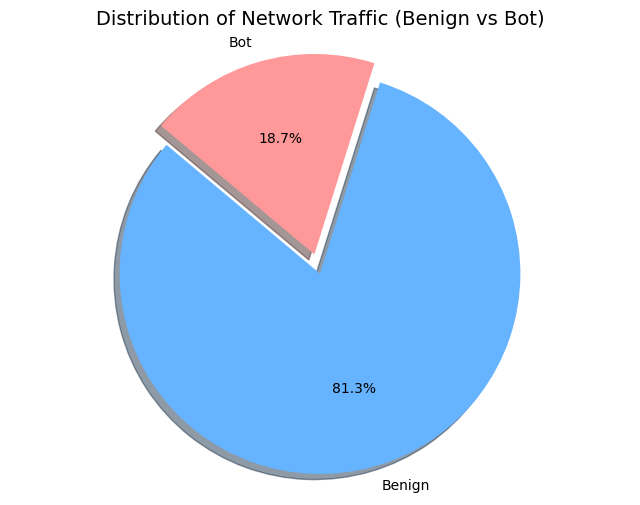

Traffic Counts:
Label
Benign    627052
Bot       144535
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt

# 1. டேட்டாவில் உள்ள 'Label' எண்ணிக்கையைக் கணக்கிடுதல்
label_counts = df['Label'].value_counts()

# 2. Pie Chart வரைதல்
plt.figure(figsize=(8, 6))
colors = ['#66b3ff', '#ff9999'] # Benign-க்கு நீலம், Bot-க்கு சிவப்பு
explode = (0, 0.1)  # Bot பகுதியை மட்டும் சற்று வெளியே தள்ளி காட்ட (Highlight)

plt.pie(label_counts, 
        labels=label_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        explode=explode, 
        shadow=True)

plt.title('Distribution of Network Traffic (Benign vs Bot)', fontsize=14)
plt.axis('equal') # வட்டம் சரியாகத் தெரிய
plt.show()

# எண்ணிக்கையை பிரிண்ட் செய்ய
print("Traffic Counts:")
print(label_counts)

## Confusion Matrix Code (Using Seaborn)

c:\Users\MALATHIKA.P\OneDrive\Documents\Smart_Shield_AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


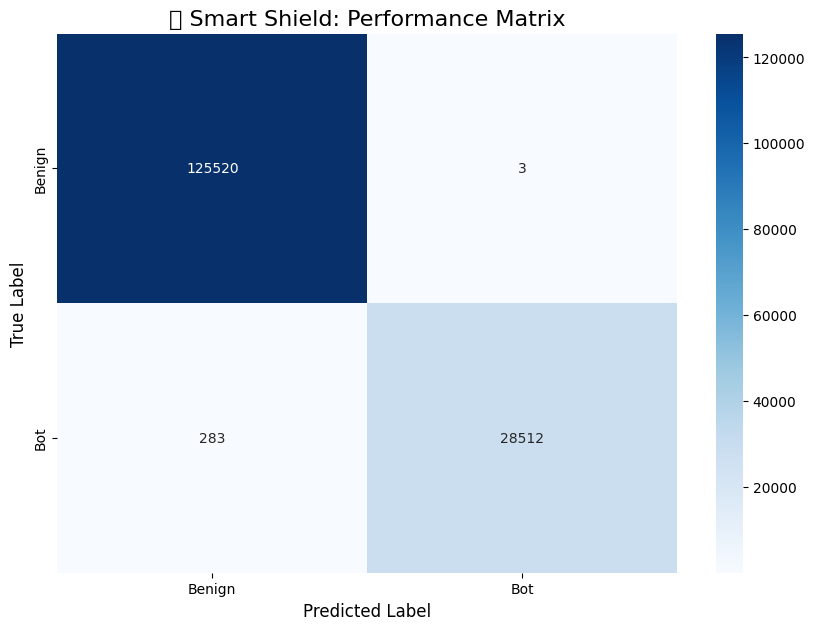

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    125523
         Bot       1.00      0.99      1.00     28795

    accuracy                           1.00    154318
   macro avg       1.00      1.00      1.00    154318
weighted avg       1.00      1.00      1.00    154318



In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# பிரிடிக்ஷன் செய்தல்
y_pred = smart_shield.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)

plt.title('🛡️ Smart Shield: Performance Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# கூடுதல் விவரம்: Precision, Recall மதிப்புகள்
print(classification_report(y_test, y_pred, target_names=le.classes_))